In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/lebron_james_2023_24_games.csv")
df.head()

,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,REB,AST,TOV,STL,BLK,PTS,PLUS_MINUS
0,22300061,2023-10-24,LAL @ DEN,L,29,10,16,1,4,0,1,8,5,0,1,0,21,7
1,22300076,2023-10-26,LAL vs. PHX,W,35,7,14,1,5,6,8,8,9,5,2,2,21,22
2,22300100,2023-10-29,LAL @ SAC,L,39,11,19,3,8,2,6,15,8,8,0,0,27,-5
3,22300111,2023-10-30,LAL vs. ORL,W,33,7,17,2,6,3,4,3,4,5,3,1,19,5
4,22300127,2023-11-01,LAL vs. LAC,W,42,13,19,4,8,5,10,12,7,4,1,2,35,6


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Game_ID     71 non-null     int64
 1   GAME_DATE   71 non-null     str  
 2   MATCHUP     71 non-null     str  
 3   WL          71 non-null     str  
 4   MIN         71 non-null     int64
 5   FGM         71 non-null     int64
 6   FGA         71 non-null     int64
 7   FG3M        71 non-null     int64
 8   FG3A        71 non-null     int64
 9   FTM         71 non-null     int64
 10  FTA         71 non-null     int64
 11  REB         71 non-null     int64
 12  AST         71 non-null     int64
 13  TOV         71 non-null     int64
 14  STL         71 non-null     int64
 15  BLK         71 non-null     int64
 16  PTS         71 non-null     int64
 17  PLUS_MINUS  71 non-null     int64
dtypes: int64(15), str(3)
memory usage: 10.1 KB


In [4]:
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
df = df.sort_values("GAME_DATE").reset_index(drop=True)

df[["GAME_DATE", "MATCHUP", "MIN", "FGA", "FG3A", "FTA", "PTS"]].tail(10)

,GAME_DATE,MATCHUP,MIN,FGA,FG3A,FTA,PTS
61,2024-03-24,LAL vs. IND,38,19,4,8,26
62,2024-03-27,LAL @ MEM,35,14,1,11,23
63,2024-03-29,LAL @ IND,35,12,3,4,16
64,2024-03-31,LAL @ BKN,37,17,10,6,40
65,2024-04-02,LAL @ TOR,29,12,1,5,23
66,2024-04-03,LAL @ WAS,36,18,1,9,25
67,2024-04-06,LAL vs. CLE,36,18,5,5,24
68,2024-04-09,LAL vs. GSW,36,22,3,5,33
69,2024-04-12,LAL @ MEM,41,20,7,11,37
70,2024-04-14,LAL @ NOP,38,20,2,6,28


In [5]:
df["HOME"] = df["MATCHUP"].apply(lambda x: 1 if "vs." in x else 0)
df["WIN"] = df["WL"].apply(lambda x: 1 if x == "W" else 0)

df[["MATCHUP", "HOME", "WL", "WIN"]].head()

,MATCHUP,HOME,WL,WIN
0,LAL @ DEN,0,L,0
1,LAL vs. PHX,1,W,1
2,LAL @ SAC,0,L,0
3,LAL vs. ORL,1,W,1
4,LAL vs. LAC,1,W,1


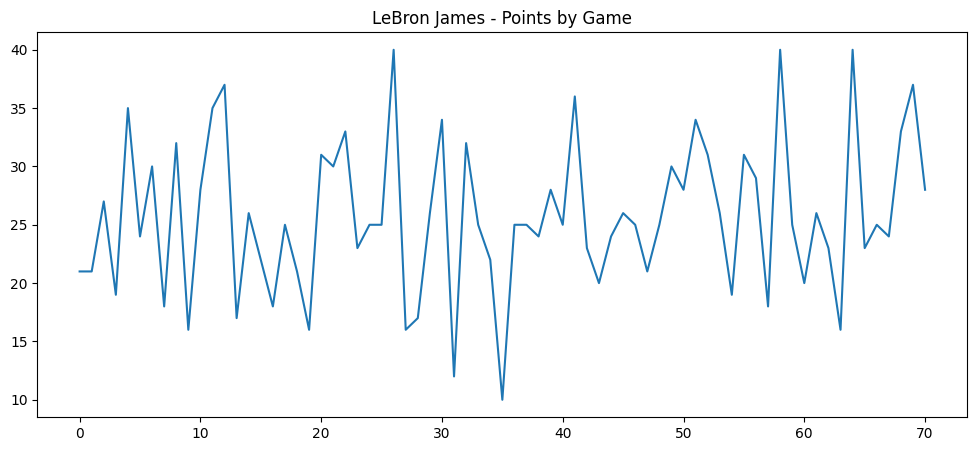

In [6]:
df["PTS"].plot(figsize=(12, 5), title="LeBron James - Points by Game")
plt.show()

In [7]:
df[["PTS", "MIN", "FGA", "FG3A", "FTA"]].describe()

,PTS,MIN,FGA,FG3A,FTA
count,71.000000,71.000000,71.000000,71.000000,71.000000
mean,25.661972,35.323944,17.873239,5.112676,5.690141
std,6.656777,4.683633,3.942188,2.314854,2.861526
min,10.000000,23.000000,10.000000,1.000000,0.000000
25%,21.000000,34.500000,15.000000,4.000000,4.000000
50%,25.000000,36.000000,18.000000,5.000000,6.000000
75%,30.000000,38.000000,20.000000,6.000000,8.000000
max,40.000000,48.000000,27.000000,12.000000,11.000000
